In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [5]:
df = pd.read_csv("smartcart_customers.csv")
df.head()


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


# Data preprocessing

## 1.Handle Missing values

In [3]:
df["Income"] = df['Income'].fillna(df['Income'].median())

In [4]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

## 2.feature engg.

In [5]:
# age 
df["Age"] = 2026-df["Year_Birth"]

In [6]:
# customer joing date
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"] , dayfirst=True)
refrence_date = df["Dt_Customer"].max()
df["cus_Tenure_days"] = (refrence_date - df["Dt_Customer"]).dt.days

In [7]:
# spending

df["tot_spending"] = df["MntWines"] + df["MntGoldProds"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntFruits"]

In [8]:
# Childerns
df["tot_children"] = df["Kidhome"] + df["Teenhome"]

In [9]:
# Educations
df["Education"] = df["Education"].replace({
    "Basic":"Undergrade" , "2n Cycle":"Undergrade",
    "Graduation" : "Graduate",
    "Master" : "Postgrad" , "PhD" : "Postgrad",
})
df["Education"].value_counts()

Education
Graduate      1127
Postgrad       856
Undergrade     257
Name: count, dtype: int64

In [10]:
# Marital_Status
df["living_with"] = df["Marital_Status"].replace({
    "Married" : "partner" , "Together" : "partner",
    "Single" : "Alone" , "Divorced" : "Alone" , "Widow" : "Alone" , "Alone" : "Alone" , "Absurd" : "Alone" , "YOLO": "Alone"
})

df["living_with"].value_counts()

living_with
partner    1444
Alone       796
Name: count, dtype: int64

In [11]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'cus_Tenure_days', 'tot_spending',
       'tot_children', 'living_with'],
      dtype='object')

In [12]:
# drop columns
cols = ["ID" , "Year_Birth" , "Marital_Status" , "Kidhome" , "Teenhome" , "Dt_Customer"]
spending_cols = ["MntWines" , "MntFruits" , "MntMeatProducts" , "MntFishProducts" , "MntSweetProducts" , "MntGoldProds"]
cols_to_drop = cols + spending_cols
df_cleaned = df.drop(columns= cols_to_drop)

In [13]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,cus_Tenure_days,tot_spending,tot_children,living_with
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,partner
4,Postgrad,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,partner


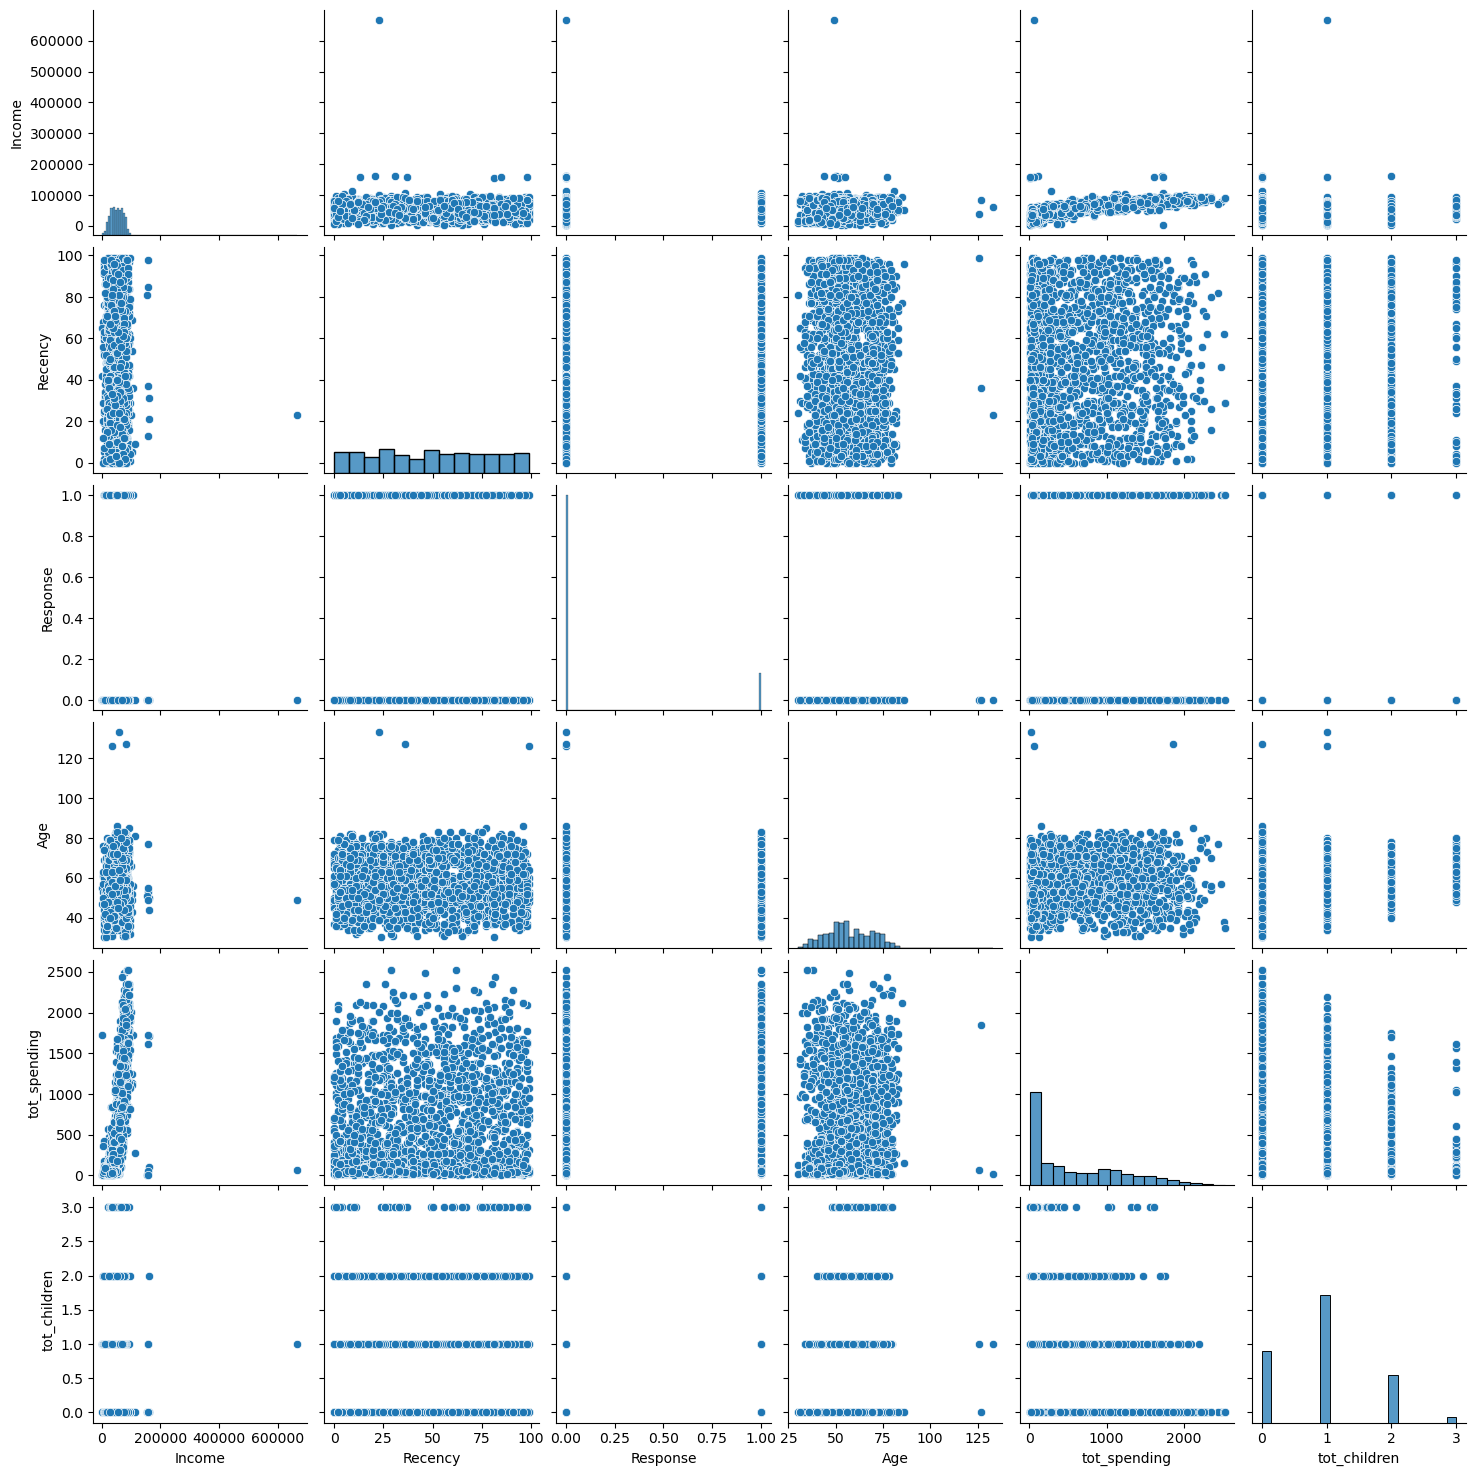

In [14]:
# Looking ouliers
import seaborn as sns
cols = ["Income" , "Recency" , "Response" , "Age" , "tot_spending" , "tot_children"]
sns.pairplot(df_cleaned[cols])

In [15]:
# remove outliers
print(f"Data with ouliers = {len(df_cleaned)}")

df_cleaned = df_cleaned[(df_cleaned["Age"] < 90)]
df_cleaned = df_cleaned[(df_cleaned["Income"] < 600_000)]

print(f"Data without ouliers = {len(df_cleaned)}")

Data with ouliers = 2240
Data without ouliers = 2236


## Heatmap

<Axes: >

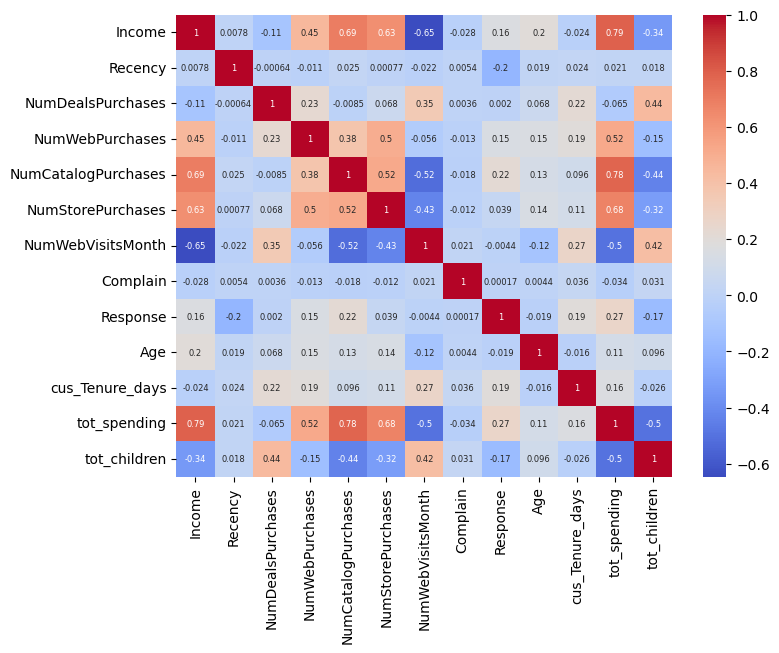

In [16]:
# Heatmap
plt.figure(figsize = (8 , 6))
corr = df_cleaned.corr(numeric_only = True)
sns.heatmap(
    corr , 
    annot = True , 
    annot_kws = {"size":6},
    cmap = "coolwarm"
)

In [17]:
# Encoding
cat_cols = ["Education" , "living_with"]
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder()
enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

## Scaling

In [18]:
enc_df = pd.DataFrame(enc_cols.toarray() , columns=ohe.get_feature_names_out(cat_cols) , index=df_cleaned.index)

In [19]:
df = pd.concat([df_cleaned.drop(columns=cat_cols) , enc_df] , axis=1)

In [2]:
x = df

NameError: name 'df' is not defined

In [3]:
x.head()

NameError: name 'x' is not defined

In [21]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [22]:
x_scaled

array([[ 0.28894655,  0.30685572,  0.34873831, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [-0.262003  , -0.38397129, -0.16869955, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.91842301, -0.7984675 , -0.68613742, ..., -0.35877969,
        -0.74204052,  0.74204052],
       ...,
       [ 0.234898  ,  1.44672029, -0.68613742, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.80780332, -1.42021181, -0.16869955, ..., -0.35877969,
        -0.74204052,  0.74204052],
       [ 0.04280841, -0.31488859,  0.34873831, ..., -0.35877969,
        -0.74204052,  0.74204052]], shape=(2236, 18))

## visualization

In [23]:
from sklearn.decomposition import PCA
pca = PCA(
    n_components = 3
)
x_pca = pca.fit_transform(x_scaled)

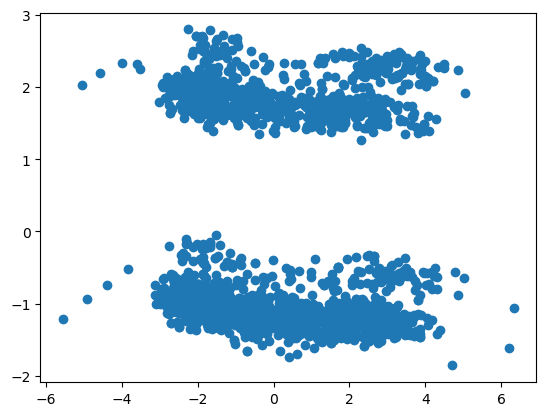

In [24]:
# plot 
plt.scatter(x = x_pca[:,0] , y = x_pca[:,1])

In [25]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, '3D - projectio')

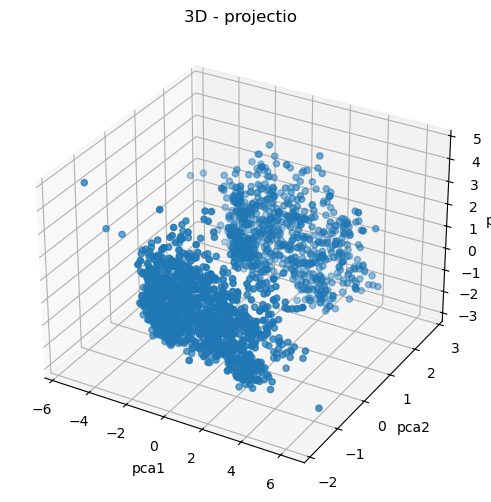

In [26]:
fig = plt.figure(figsize = (8,6))
ax = fig.add_subplot(111 , projection = "3d")
ax.scatter(x_pca[:,0] , x_pca[:,1] , x_pca[:,2])

ax.set_xlabel("pca1")
ax.set_ylabel("pca2")
ax.set_zlabel("pca3")
ax.set_title("3D - projectio")

# Analysis k value

## Elbow method

In [27]:
from sklearn.cluster import KMeans
from kneed import KneeLocator 

wcss = []
for k in range(1 , 11):
    kmeans = KMeans(n_clusters = k , random_state =42)
    kmeans.fit_predict(x_pca)
    wcss.append(kmeans.inertia_)

In [28]:
knee = KneeLocator(range(1 , 11) , wcss , curve='convex' , direction='decreasing')

optima_k = knee.elbow
optima_k

np.int64(4)

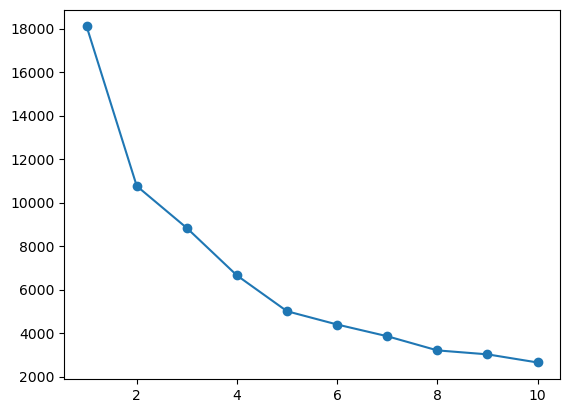

In [29]:
plt.plot(range(1 , 11) , wcss , marker='o')

## Silhouette score

In [30]:
from sklearn.metrics import silhouette_score
scores = []
for k in range(2 , 11):
    kmeans = KMeans(n_clusters=k , random_state =42)
    labels = kmeans.fit_predict(x_pca)
    score = silhouette_score(x_pca , labels)
    scores.append(score)

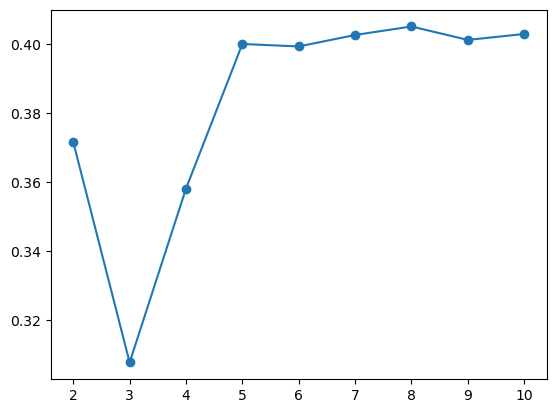

In [31]:
# plot 
plt.plot(range(2 , 11) , scores , marker='o')

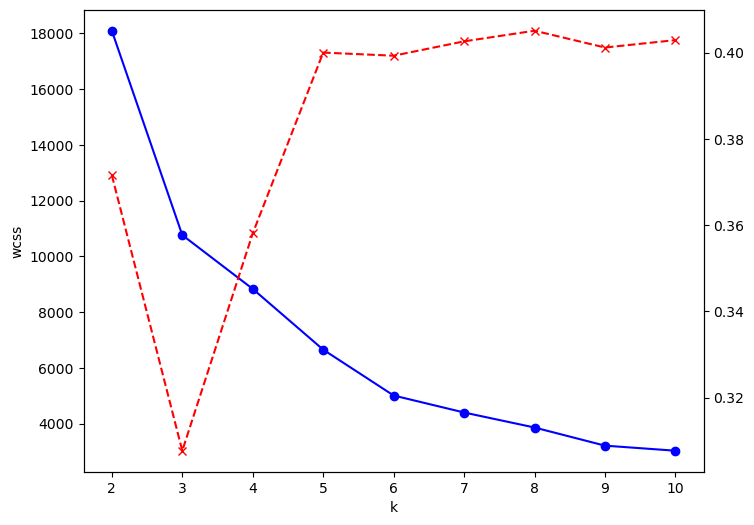

In [32]:
# compline plot
k_range = range(2,11)
fig , ax1 = plt.subplots(figsize=(8,6))
ax1.plot(k_range , wcss[:len(k_range)] , marker = 'o' , color='blue')

ax1.set_xlabel("k")
ax1.set_ylabel("wcss")

ax2 = ax1.twinx()
ax2.plot(k_range , scores[:len(k_range)] , marker = 'x' , color='red' , linestyle='--')

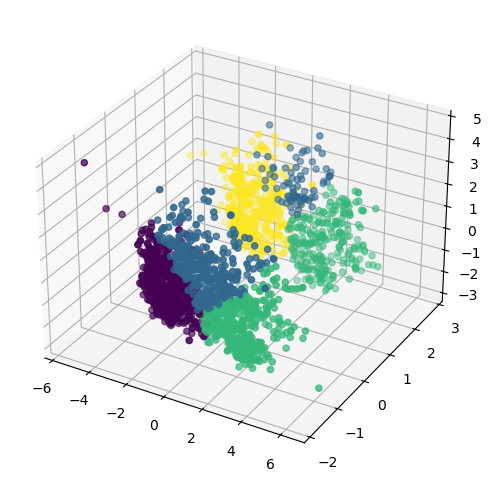

In [33]:
# clustering
kmeans = KMeans(n_clusters = 4 , random_state = 42)
labels_kmeans = kmeans.fit_predict(x_pca)

fig = plt.figure(figsize = (8,6))
ax = fig.add_subplot(111 , projection = "3d")
ax.scatter(x_pca[:,0] , x_pca[:,1] , x_pca[:,2] , c=labels_kmeans)

In [34]:
from sklearn.cluster import AgglomerativeClustering

clf_agg = AgglomerativeClustering(n_clusters = 4 , linkage='ward')
agg_labels = clf_agg.fit_predict(x_pca)

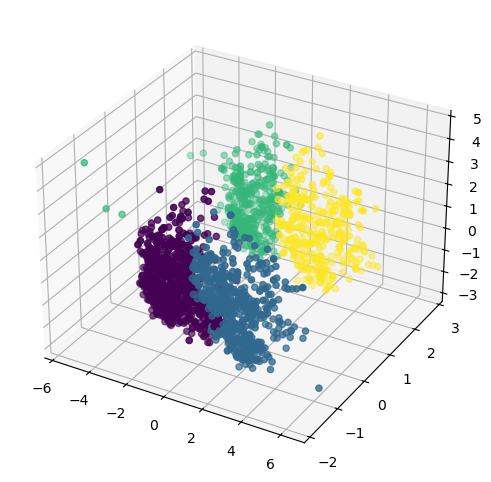

In [35]:
fig = plt.figure(figsize = (8,6))
ax = fig.add_subplot(111 , projection = "3d")
ax.scatter(x_pca[:,0] , x_pca[:,1] , x_pca[:,2] , c=agg_labels)

## Characterization of cluster

In [51]:
x["cluster"] = agg_labels

In [54]:
x.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,cus_Tenure_days,tot_spending,tot_children,Education_Graduate,Education_Postgrad,Education_Undergrade,living_with_Alone,living_with_partner,labels,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0,0


<Axes: xlabel='cluster', ylabel='count'>

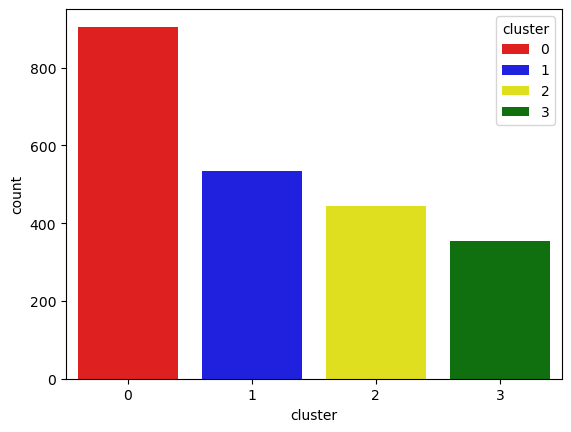

In [53]:
pal = ["red", "blue" , "yellow" , "green"]
sns.countplot(x=x["cluster"] , palette=pal , hue=x["cluster"])

<Axes: xlabel='tot_spending', ylabel='Income'>

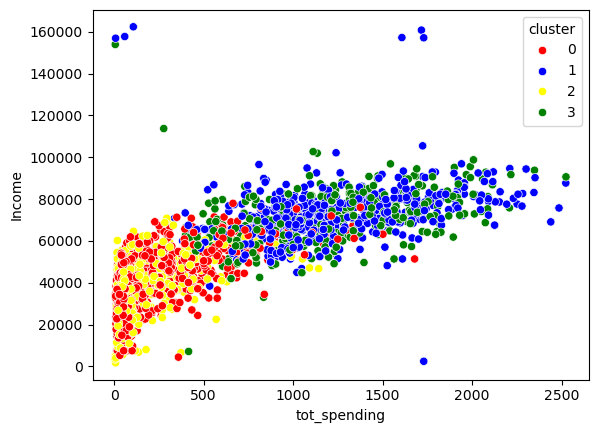

In [55]:
# spending & income
sns.scatterplot(x=x["tot_spending"] , y=x["Income"] , hue=x["cluster"], palette=pal)

## Cluster summry

In [58]:
cluster_summry = x.groupby("cluster").mean()

In [59]:
print(cluster_summry)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        39680.580110  48.914917           2.594475         3.153591   
1        72808.445693  49.202247           1.958801         5.687266   
2        36960.143018  48.319820           2.594595         2.713964   
3        70722.681303  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        Age  cus_Tenure_days  tot_spending  tot_children  \
cluster  